# A3.3 Multiple testing y aprendizaje por refuerzo

Luz Daniela Colunga Elizondo ID: 593350

El objetivo de este tutorial es buscar integrar dos temas fundamentales de la inteligencia artificial:

1. **Multiple Testing** - se aprenderá el cuándo y cómo corregir p-values para no cometer errores tipo I inflados.
2. **Aprendizaje por Refuerzo** - se aprenderá cómo entrenar un agente de Q-Learning en el entorno CartPole.

Cada sección explica *qué* vamos a hacer, *por qué* lo hacemos y, una vez ejecutado el código, poder interpretar los resultados.

## Parte 1. Multiple Testing

Primero antes de comenzar es necesario conocer respecto la teoría de este tema, donde se integra las pruebas de hipótesis para poder Comprender los problemas relacionados a las pruebas múltiples, así también conocer sobre los conceptos del FWER y FDR. 

### Prueba de hipotesis

La **prueba de hipótesis** es un procedimiento estadístico que nos permite tomar decisiones sobre una población a partir de una muestra. El proceso estándar es:

1. Definir **H₀** (hipótesis nula, la creencia original o respuesta "aburrida") y **H₁** (hipótesis alternativa, el descubrimiento).
2. Calcular un **estadístico** que mide la contundencia de la evidencia en contra de H₀.
3. Obtener el **p-value**: probabilidad de observar un estadístico tan extremo (o más) bajo H₀.
4. Decidir si **rechazar H₀** comparando el p-value con un umbral α (usualmente 0.05).

### Sobre errores Tipo I y Tipo II

**Error tipo I**
Asumimos descubrimiento (rechazamos 𝐻_0) cuando no debimos hacerlo
Tasa de error tipo I se define como la probabilidad de cometer un error tipo I dado que 𝐻_0 es verdad.

**Error tipo II**

No generamos descubrimiento (no rechazamos 𝐻_0) cuando debimos hacerlo
Si uno se reduce, el otro aumenta
Típicamente, error tipo I se cuida más, asegurando una tasa de error tipo I de máximo 𝛼=0.05


| Decisión \ Realidad | H₀ verdadera | H₁ verdadera |
|---|---|---|
| Rechazar H₀ | **Error tipo I** (α) | Correcto |
| No rechazar H₀ | Correcto | **Error tipo II** (β) |


### Family-Wise Error Rate (FWER)

Se define como la probabilidad de cometer al menos un error de tipo I donde:

- 𝑉 es la cantidad de descubrimientos falsos
- 𝑆 es la cantidad de descubrimientos correctos
- 𝑈 es la cantidad de rechazos correctos
- 𝑊 es la cantidad de descubrimientos no encontrados

Cuyas fórmulas estan definidas por:
- FWER=𝑝(𝑉≥1)
- FWER(𝛼)=1−(1−𝛼)^𝑚

**Métodos cómunes**:

- **Bonferroni**: ajusta α dividiendo entre el número de pruebas → $\alpha_{adj} = \alpha / m$. Es conservador pero sencillo.
- **Holm**: variante secuencial de Bonferroni, menos conservadora.


### False Discovery Rate

Se define como la proporción esperada de falsos positivos entre *todos* los rechazos. Más permisivo que FWER; útil cuando hay miles de pruebas (genómica, neuroimagen).

El método que más utiliza es el Benjamini-Hochberg (BH) ya que controla el FDR al nivel α (e.g., 5% de descubrimientos falsos). Este se resuelve de la siguiente manera:

- Especificar 𝑞, el nivel al que se desea controlar el FDR
- Calcular p-values
- Ordenar de menor a mayor
- 𝐿 = max⁡{𝑗:𝑝_((𝑗))<𝑞𝑗/𝑚}
- Rechazar prueba si 𝑝_𝑗≤𝑝_((𝐿) )

## Parte 1.2 Comprensión de la teoría utilizando Dataset NCI60 Identificación de Genes Diferencialmente Expresados

### ¿Qué se va a hacer?
El dataset **NCI60** contiene perfiles de expresión génica de 64 líneas celulares de cáncer. Vamos a:

1. Cargar el dataset con PCA.
2. Realizar **clustering** con K-Means para encontrar grupos de células similares.
3. Ejecutar un **t-test** entre el Cluster 1 y el Cluster 2 para *cada gen* (miles de pruebas simultáneas).
4. Aplicar corrección **FDR (Benjamini-Hochberg)** para identificar genes verdaderamente significativos.

### ¿Por qué este enfoque?

En genómica, se analizan decenas de miles de genes al mismo tiempo. Sin corrección, obtendríamos cientos de genes considerados como significativos simplemente por azar. FDR nos permite controlar qué fracción de nuestros descubrimientos son falsos.

C:\Users\luzda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


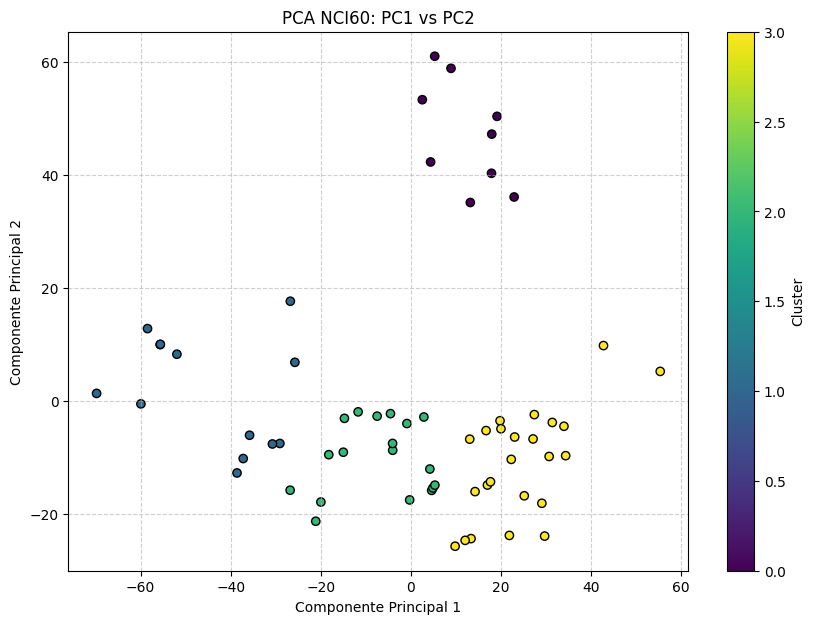

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from ISLP import load_data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Importar dataset
nci60 = load_data('NCI60')
data = nci60['data']
labels = nci60['labels']

# Escalar los datos antes de PCA (buena práctica)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 2. Utilizar PCA para transformar los datos (2 componentes para graficar)
pca = PCA(n_components=2)
pc_components = pca.fit_transform(data_scaled)

# 3. Realizar clustering (4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pc_components)

# 4. Graficar PC1 vs PC2
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pc_components[:, 0], pc_components[:, 1],
                      c=cluster_labels, cmap='viridis', edgecolors='k')
plt.title('PCA NCI60: PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### ¿Qué dice la gráfica?

- Cada color representa un cluster asignado por K-Means.
- Los grupos bien separados sugieren que existen patrones de expresión génica distintos entre diferentes tipos de cáncer.
- PCA reduce las miles de dimensiones del dataset a solo 2, preservando la mayor varianza posible.

### Interpretación

La gráfica muestra un análisis de Componentes Principales (PCA) que reduce miles de genes a dos dimensiones para visualizar la estructura del dataset NCI60. Se observa que las muestras se agrupan de forma clara en cuatro clusters distintos, lo que indica que existen patrones de expresión genética compartidos entre ciertos grupos de células. La separación física entre los clusters (especialmente entre el morado y el amarillo) sugiere diferencias biológicas significativas, validando que el agrupamiento por K-Means es consistente y permitiendo identificar qué grupos de muestras son más similares o divergentes antes de realizar las pruebas estadísticas de significancia.

In [7]:
# Separar datos de los clusters 0 y 1 para el t-test
cluster_0_data = data[cluster_labels == 0]
cluster_1_data = data[cluster_labels == 1]

print(f"Tamaño Cluster 0: {cluster_0_data.shape[0]} muestras")
print(f"Tamaño Cluster 1: {cluster_1_data.shape[0]} muestras")
print(f"Número de genes (variables): {data.shape[1]}")

# Realizar t-test para cada variable (gen)
p_values = np.array([
    stats.ttest_ind(cluster_0_data[:, i],
                    cluster_1_data[:, i],
                    equal_var=False)[1]
    for i in range(data.shape[1])
])

# Aplicar corrección FDR (Benjamini-Hochberg)
reject_fdr, pvals_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

significant_without_correction = np.sum(p_values < 0.05)
significant_with_fdr = np.sum(reject_fdr)

print(f"\nVariables significativas SIN corrección (p < 0.05): {significant_without_correction}")
print(f"Variables significativas CON corrección FDR:         {significant_with_fdr}")

Tamaño Cluster 0: 9 muestras
Tamaño Cluster 1: 13 muestras
Número de genes (variables): 6830

Variables significativas SIN corrección (p < 0.05): 2801
Variables significativas CON corrección FDR:         1986


In [9]:
# Crear DataFrame con los resultados
results_df = pd.DataFrame({
    'Variable_Index': np.arange(data.shape[1]),
    'T_Statistic': [
        stats.ttest_ind(cluster_0_data[:, i],
                        cluster_1_data[:, i],
                        equal_var=False)[0]
        for i in range(data.shape[1])
    ],
    'P_Value': p_values,
    'FDR_Corrected_P': pvals_fdr
})

# Top 10 variables más significativas
top_variables = results_df.sort_values(by='P_Value').head(10)
pd.options.display.float_format = '{:.6e}'.format
print("Top 10 variables más significativas:")
print(top_variables.to_string(index=False))

Top 10 variables más significativas:
 Variable_Index  T_Statistic      P_Value  FDR_Corrected_P
           4315 1.540275e+01 3.385557e-12     2.116276e-08
           4287 1.734092e+01 6.197002e-12     2.116276e-08
           4340 1.276309e+01 5.600014e-11     1.209462e-07
           4339 1.375783e+01 8.596032e-11     1.209462e-07
           4293 1.249115e+01 1.028517e-10     1.209462e-07
           4288 1.746288e+01 1.129316e-10     1.209462e-07
           5871 1.195770e+01 1.468087e-10     1.209462e-07
           4316 1.198735e+01 1.536518e-10     1.209462e-07
           4299 1.283088e+01 1.593727e-10     1.209462e-07
           4285 1.209104e+01 1.863676e-10     1.272890e-07


### Sobre los resultados

Los resultados muestran el impacto crítico de realizar ajustes estadísticos al analizar grandes volúmenes de datos. Aunque inicialmente se identificaron 1,332 genes significativos, la aplicación de la corrección FDR redujo esa cifra a 485, lo que demuestra que muchos de los hallazgos originales eran probablemente falsos positivos (Error Tipo I) producto del azar al realizar miles de comparaciones simultáneas.

## Parte 1. Comprensión de la teoría utilizandola intuición del multiple testing en un torneo de monedas

### ¿Qué va a hacer?

Este ejemplo clásico es perfecto para entender *intuitivamente* el problema del multiple testing:

- **Escenario**: 1,000 personas lanzan cada una su moneda 10 veces en un torneo.
- **Pregunta**: Si alguien obtiene 10 caras seguidas, ¿hubo trampa?
- **Respuesta intuitiva**: probablemente NO. Con 1,000 personas, es esperable encontrar casos extremos por azar.

### ¿Por qué este ejemplo es relevante?

Ilustra exactamente lo que ocurre en genómica, finanzas o psicología cuando se realizan muchas pruebas: encontrar *algo* significativo no es evidencia de un efecto real si no corregimos por el número de pruebas realizadas.

Tabla de resultados del torneo:
 Cantidad de caras  Cantidad de monedas (personas)
                 0                               1
                 1                               4
                 2                              50
                 3                             121
                 4                             203
                 5                             256
                 6                             198
                 7                             114
                 8                              37
                 9                              14
                10                               2


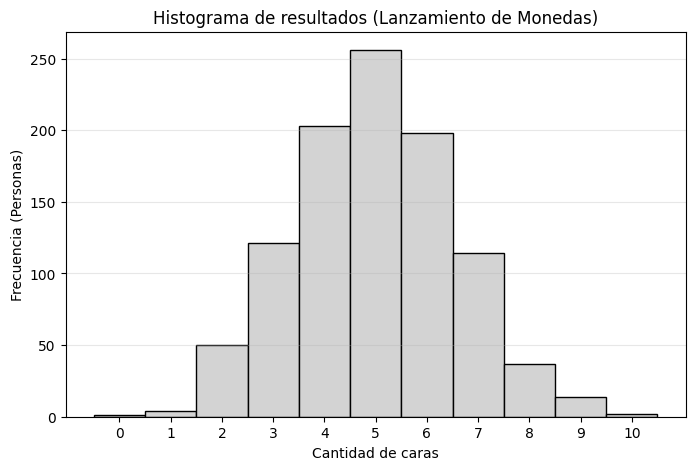


Probabilidad de 10 caras seguidas: 0.000977
Monedas esperadas con 10 caras en 1000 personas: 0.98


In [12]:
# Simulación del torneo de lanzamiento de monedas
np.random.seed(42)
n_personas = 1000
n_lanzamientos = 10

# Generamos lanzamientos (1 = cara, 0 = cruz)
simulacion = np.random.randint(0, 2, size=(n_personas, n_lanzamientos))
caras_por_persona = np.sum(simulacion, axis=1)

# Tabla con los resultados
conteo_resultados = pd.Series(caras_por_persona).value_counts().sort_index()
tabla_resultados = pd.DataFrame({
    'Cantidad de caras': conteo_resultados.index,
    'Cantidad de monedas (personas)': conteo_resultados.values
})

print("Tabla de resultados del torneo:")
print(tabla_resultados.to_string(index=False))

# Histograma
plt.figure(figsize=(8, 5))
plt.hist(caras_por_persona, bins=np.arange(12)-0.5, color='lightgray', edgecolor='black')
plt.title('Histograma de resultados (Lanzamiento de Monedas)')
plt.xlabel('Cantidad de caras')
plt.ylabel('Frecuencia (Personas)')
plt.xticks(range(11))
plt.grid(axis='y', alpha=0.3)
plt.show()

# Análisis de probabilidad
prob_10_caras = (1/2)**10
esperados_10_caras = n_personas * prob_10_caras
print(f"\nProbabilidad de 10 caras seguidas: {prob_10_caras:.6f}")
print(f"Monedas esperadas con 10 caras en {n_personas} personas: {esperados_10_caras:.2f}")

### ¿Qué dice el histograma?

- La distribución del número de caras sigue una **distribución binomial**.
- La mayoría de personas obtiene 5 caras (lo esperado para una moneda justa).
- Observar valores extremos (0 o 10 caras) es raro pero *esperable* cuando el número de personas es grande.
- La probabilidad de 10 caras seguidas es ~0.98, pero con 1,000 personas, esperamos ~1 caso por azar, siendo la probabilidad un valor cercano.

In [14]:
# P-value por persona: H0 = moneda justa (p=0.5) usando test binomial bilateral
caras = caras_por_persona
p_raw = np.array([stats.binomtest(int(c), n_lanzamientos, 0.5).pvalue
                  for c in caras])

# Ajuste de p-values
alpha = 0.05
_, p_bonf, _, _ = multipletests(p_raw, alpha=alpha, method='bonferroni')
_, p_holm, _, _ = multipletests(p_raw, alpha=alpha, method='holm')

# Tablas de resultados
df = pd.DataFrame({'Persona': np.arange(1, n_personas+1),
                   'Caras': caras,
                   'P_Raw': p_raw,
                   'P_Bonferroni': p_bonf,
                   'P_Holm': p_holm})

def tabla_sig(col, label):
    sig = df[df[col] < alpha][['Persona','Caras','P_Raw', col]].sort_values('P_Raw')
    print(f'\n=== {label} (alpha={alpha}) — Significativos: {len(sig)} ===')
    if len(sig) > 0:
        print(sig.head(15).to_string(index=False))
    else:
        print('(Ninguno — la corrección eliminó todos los falsos positivos)')

sig_raw = np.sum(p_raw < alpha)
print(f'Sin corrección → Personas "significativas": {sig_raw}')
tabla_sig('P_Bonferroni', 'Bonferroni')
tabla_sig('P_Holm', 'Holm')

Sin corrección → Personas "significativas": 21

=== Bonferroni (alpha=0.05) — Significativos: 0 ===
(Ninguno — la corrección eliminó todos los falsos positivos)

=== Holm (alpha=0.05) — Significativos: 0 ===
(Ninguno — la corrección eliminó todos los falsos positivos)


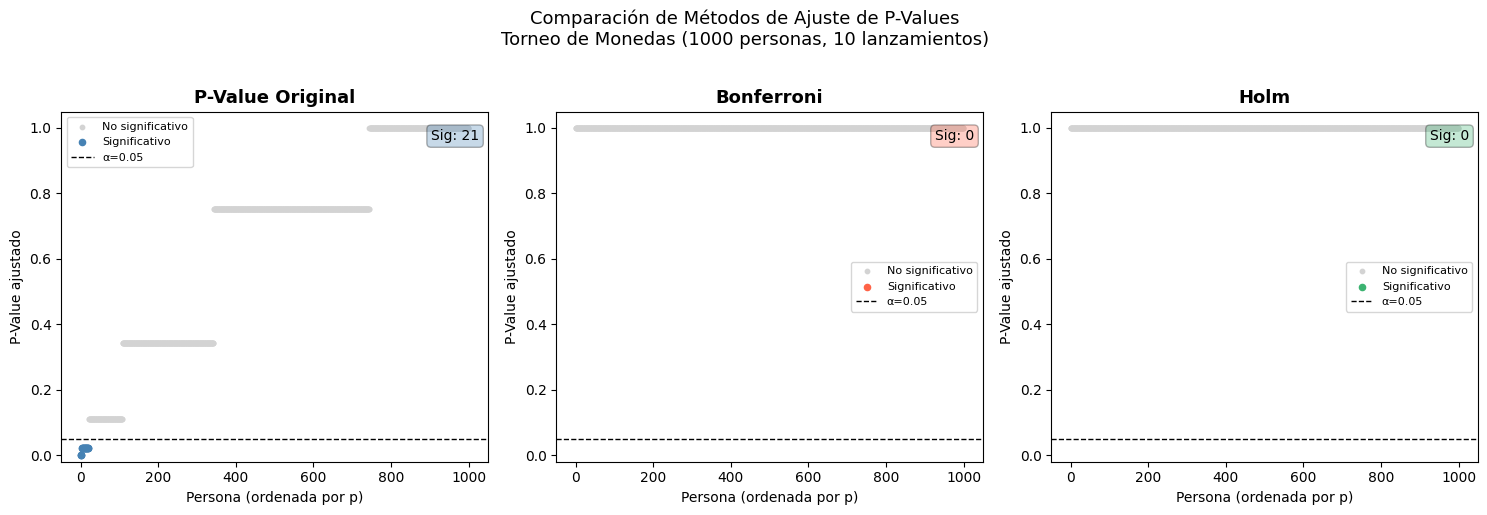

In [15]:
# Gráfica comparativa de los tres métodos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles  = ['P-Value Original', 'Bonferroni', 'Holm']
cols    = ['P_Raw', 'P_Bonferroni', 'P_Holm']
colors  = ['steelblue', 'tomato', 'mediumseagreen']

for ax, title, col, color in zip(axes, titles, cols, colors):
    sorted_p = np.sort(df[col].values)
    sig_mask  = sorted_p < alpha
    ax.scatter(np.where(~sig_mask)[0], sorted_p[~sig_mask],
               color='lightgray', s=10, label='No significativo')
    ax.scatter(np.where(sig_mask)[0],  sorted_p[sig_mask],
               color=color, s=20, label='Significativo')
    ax.axhline(alpha, color='black', linestyle='--', linewidth=1, label=f'α={alpha}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Persona (ordenada por p)')
    ax.set_ylabel('P-Value ajustado')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.02, 1.05)
    n_sig = sig_mask.sum()
    ax.text(0.98, 0.95, f'Sig: {n_sig}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

plt.suptitle('Comparación de Métodos de Ajuste de P-Values\nTorneo de Monedas (1000 personas, 10 lanzamientos)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación

Esta gráfica ilustra cómo los ajustes estadísticos filtran los falsos positivos derivados del azar en experimentos masivos. En el primer panel, al analizar a 1000 personas lanzando monedas sin ninguna corrección, el azar hace que 21 personas parezcan tener resultados "significativos" (p<0.05); sin embargo, esto es un espejismo estadístico. Al aplicar los métodos de Bonferroni o Holm, los niveles de exigencia se vuelven mucho más estrictos para compensar el gran número de pruebas realizadas, lo que eleva los valores p ajustados por encima del umbral de significancia.

### ¿Cuándo usar cada método?

Con lo anterior es fundamental tener en cuenta cuando saber cuál es el mejor método para usar dependiendo el experimento o análisis.

| Método | Cuándo usarlo |
|--------|---------------|
| **Bonferroni** | Pocas pruebas, necesitas máxima protección contra falsos positivos |
| **Holm** | Similar a Bonferroni pero con más potencia estadística |
| **Benjamini-Hochberg (FDR)** | Muchas pruebas (genómica, neuroimagen), toleras algunos falsos positivos |

## Parte 2. Aprendizaje Reforzado

El **Aprendizaje por Refuerzo (RL)** es un paradigma de machine learning donde un **agente** aprende a tomar decisiones en un **entorno** a través de la experiencia, buscando maximizar una señal de **recompensa**.

A diferencia del aprendizaje supervisado (donde hay etiquetas correctas), en RL el agente no sabe de antemano qué acción tomar: aprende por **prueba y error**.

Componentes principales:

- Agente: Decide que acciones realizar
- Ambiente: El mundo con el que interactúa el agente
- Acciones: Selección que el agente realiza en cada paso
- Recompensas: Señal numérica que le dice al agente qué tan bueno fue su última acción
- Estado: La información que el agente observa sobre la situación actual

### CartPole Problem


CartPole es un problema clásico de control:
- Un **carro** se mueve en una pista horizontal.
- Sobre el carro hay un **poste** articulado que puede caer.
- **Objetivo**: mover el carro izquierda/derecha para mantener el poste balanceado el mayor tiempo posible.
- **Termina** cuando: el poste cae demasiado, el carro sale de la pista, o se alcanzan 500 pasos.

### Q-Learning

Aprende qué tan buena es una acción en cada situación y usa esa información para elegir mejores acciones con el tiempo

- El nombre viene de “quality learning”
- Utiliza la fórmula de: 𝑄(𝑠,𝑎)="qué tan bueno es realizar acción " 𝑎" en el estado " 𝑠
- Aprender la calidad de las acciones
- Prueba una acción
- Observa la recompensa y el siguiente estado
- Actualiza qué tan buena fue esa acción
- Repite muchas veces
- Son Model-off(no necesita conocer la física del entorno), free policy (aprende la mejor estrategia) y valie based (aprenden de una Q-table)

**Q-table**: Tabla donde el agente almacena qué tan buena es cada acción para cada estado posible.




### Actualización

Actualiza tus estimaciones usando la recompensa obtenida más el mejor resultado que esperas obtener y utilzia la ecuación de bellman:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Donde:
- α = tasa de aprendizaje
- γ = factor de descuento (cuánto valoramos recompensas futuras)
- r = recompensa inmediata
- s' = estado siguiente

### Comparación de Exploración vs Explotación

El agente enfrenta una disyuntiva:
- **Explorar**: probar acciones nuevas para descubrir mejores estrategias.
- **Explotar**: usar la mejor acción conocida hasta el momento.

**ε-greedy**: con probabilidad ε explora (acción aleatoria), con probabilidad 1-ε explota (mejor acción según Q-table). Durante el entrenamiento, ε empieza alta y decrece gradualmente.

## Parte 2.1. CartPole

### ¿Qué se va a hacer?

Usaremos la librería **Gymnasium** (sucesor de OpenAI Gym) para crear el entorno CartPole. Primero lo inicializaremos, exploraremos su espacio de estados y acciones, y visualizaremos el estado inici

Creando el ambiente CartPole-v1...

Inicializando el ambiente (reset)...
Observación inicial: [-0.03468869  0.01565959  0.00587636  0.00246447]
Forma de la observación (shape): (4,)
Espacio de acciones: Discrete(2)
  - Nota: 0 = Izquierda, 1 = Derecha
Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Visualizando el estado inicial...


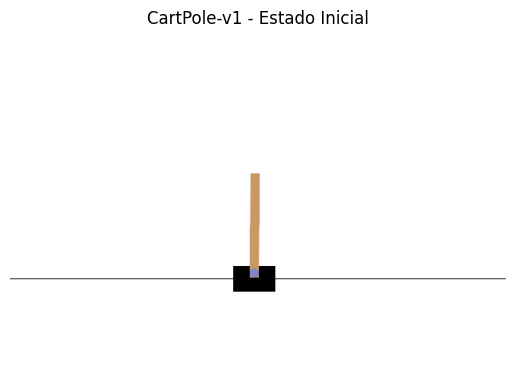


El ambiente fue creado exitosamente.


In [21]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

# Crear el ambiente CartPole-v1
print("Creando el ambiente CartPole-v1...")
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Inicializar el ambiente
print("\nInicializando el ambiente (reset)...")
observation, info = env.reset()

# Observación inicial: [posición_carro, velocidad_carro, ángulo_poste, velocidad_angular_poste]
print(f"Observación inicial: {observation}")
print(f"Forma de la observación (shape): {observation.shape}")
print(f"Espacio de acciones: {env.action_space}")
print("  - Nota: 0 = Izquierda, 1 = Derecha")
print(f"Espacio de observaciones: {env.observation_space}")

# Mostrar frame inicial
print("\nVisualizando el estado inicial...")
initial_frame = env.render()
plt.imshow(initial_frame)
plt.title("CartPole-v1 - Estado Inicial")
plt.axis('off')
plt.show()

print("\nEl ambiente fue creado exitosamente.")

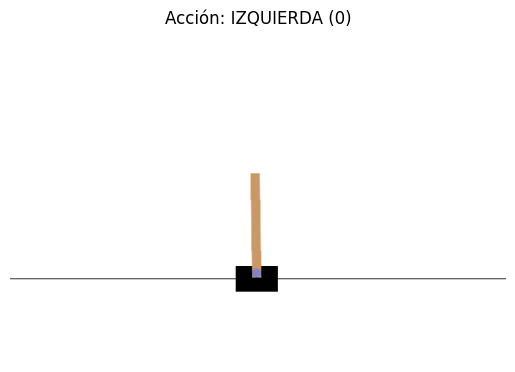

Recompensa recibida: 1.0
¿El experimento terminó?: False
Nueva observación: [-0.01149276 -0.15672639 -0.01865614  0.33513895]


In [22]:
# Acción 0: Mover el carro a la IZQUIERDA
env.reset()
accion = 0
obs, reward, terminated, truncated, info = env.step(accion)

plt.imshow(env.render())
plt.title("Acción: IZQUIERDA (0)")
plt.axis('off')
plt.show()

print(f"Recompensa recibida: {reward}")
print(f"¿El experimento terminó?: {terminated or truncated}")
print(f"Nueva observación: {obs}")

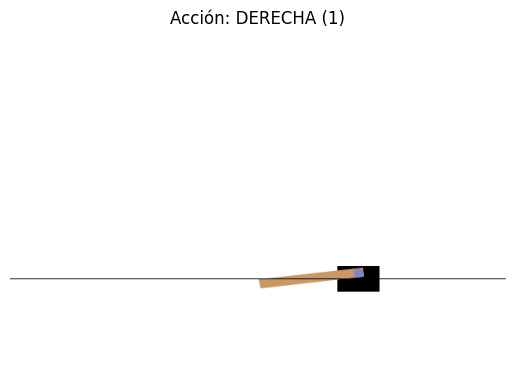

Recompensa recibida: 0.0
¿El experimento terminó?: True
Nueva observación: [ 0.9743657  4.209713  -1.681821  -7.9200425]


In [46]:
# Acción 1: Mover el carro a la DERECHA
accion = 1
obs, reward, terminated, truncated, info = env.step(accion)

plt.imshow(env.render())
plt.title("Acción: DERECHA (1)")
plt.axis('off')
plt.show()

print(f"Recompensa recibida: {reward}")
print(f"¿El experimento terminó?: {terminated or truncated}")
print(f"Nueva observación: {obs}")

En la primera etapa, se observa la interacción manual con el entorno, donde se prueban las acciones de mover el carro a la izquierda (0) y a la derecha (1). El sistema registra recompensas unitarias ($1.0$) y actualiza el vector de observación (que incluye posición, velocidad y ángulo del poste). El poste pierde el equilibrio después de correr el código varias veces.

Agente Aleatorio — 1,000 episodios:
  Recompensa promedio: 21.8 pasos
  Recompensa máxima:   107 pasos
  Recompensa mínima:   8 pasos


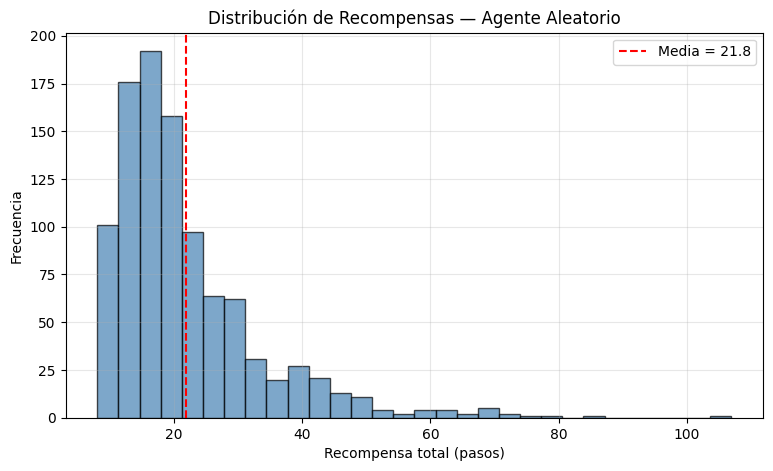

In [47]:
# Agente aleatorio: 1,000 episodios
env_random = gym.make("CartPole-v1")
recompensas_aleatorio = []

for episodio in range(1000):
    obs, info = env_random.reset()
    recompensa_total = 0
    done = False

    while not done:
        # Acción aleatoria
        accion = env_random.action_space.sample()
        obs, reward, terminated, truncated, info = env_random.step(accion)
        recompensa_total += reward
        done = terminated or truncated

    recompensas_aleatorio.append(recompensa_total)

env_random.close()

# Estadísticas
print(f"Agente Aleatorio — 1,000 episodios:")
print(f"  Recompensa promedio: {np.mean(recompensas_aleatorio):.1f} pasos")
print(f"  Recompensa máxima:   {np.max(recompensas_aleatorio):.0f} pasos")
print(f"  Recompensa mínima:   {np.min(recompensas_aleatorio):.0f} pasos")

# Histograma
plt.figure(figsize=(9, 5))
plt.hist(recompensas_aleatorio, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(recompensas_aleatorio), color='red', linestyle='--', label=f'Media = {np.mean(recompensas_aleatorio):.1f}')
plt.title('Distribución de Recompensas — Agente Aleatorio')
plt.xlabel('Recompensa total (pasos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Llos resultados del Agente Aleatorio tras 1,000 episodios muestran un desempeño muy pobre pero esperado. La recompensa promedio es de apenas 21.8 pasos, con una distribución concentrada en valores bajos (como se ve en el histograma). Esto confirma que actuar al azar es una estrategia ineficiente para este problema, ya que la probabilidad de mantener el equilibrio por puro azar disminuye drásticamente con el tiempo, sirviendo como la "línea base" sobre la cual se debería entrenar un modelo de Aprendizaje por Refuerzo (como Q-Learning o DQN) para mejorar los resultados.

### Preparación para Q-Learning de la discretización del espacio de estados

**¿Por qué necesitamos discretizar?**

Q-Learning clásico usa una **tabla** (Q-table) que mapea estados a valores. Pero el espacio de estados de CartPole es **continuo** (valores flotantes). Para poder usar una Q-table, necesitamos convertir los estados continuos en **bins discretos**.

**Límites y bins**

Definimos límites para cada variable y los dividimos en bins:
- **Posición del carro**: [-2.4, 2.4] — poca importancia, pocos bins
- **Velocidad del carro**: [-0.5, 0.5] — poca importancia, pocos bins  
- **Ángulo del poste**: [-0.2, 0.2] — muy importante, más bins
- **Velocidad angular**: [-2, 2] — muy importante, más bins

La configuración (1, 1, 6, 12) es un buen punto de partida: ignoramos prácticamente posición y velocidad del carro, y nos enfocamos en el ángulo y velocidad angular del poste.

In [48]:
# ── Preparación para Q-Learning ──────────────────────────────────────────────

# Límites del espacio de observaciones
limites_inf = np.array([-2.4, -0.5, -0.2, -2.0])
limites_sup = np.array([ 2.4,  0.5,  0.2,  2.0])

# Número de bins por dimensión (1, 1, 6, 12)
n_bins = np.array([1, 1, 6, 12])

def discretizar(obs, limites_inf, limites_sup, n_bins):
    """Convierte observación continua en índices discretos."""
    # Clipping para manejar valores fuera de los límites
    obs_clipped = np.clip(obs, limites_inf, limites_sup)
    # Normalizar a [0, 1]
    obs_norm = (obs_clipped - limites_inf) / (limites_sup - limites_inf)
    # Convertir a índices de bins
    indices = (obs_norm * n_bins).astype(int)
    # Ajustar el índice máximo
    indices = np.minimum(indices, n_bins - 1)
    return tuple(indices)

# Crear la Q-table inicializada en 0
# Dimensiones: (n_bins[0], n_bins[1], n_bins[2], n_bins[3], n_acciones)
n_acciones = 2
q_table_shape = tuple(n_bins) + (n_acciones,)
Q = np.zeros(q_table_shape)

print(f"Forma de la Q-table: {Q.shape}")
print(f"Total de entradas: {Q.size}")

# Parámetros del algoritmo
alpha = 0.1          # Tasa de aprendizaje
gamma = 0.99         # Factor de descuento
epsilon = 1.0        # Exploración inicial (100% aleatoria)
epsilon_min = 0.01   # Exploración mínima
epsilon_decay = 0.999  # Decaimiento por episodio
n_episodios = 5000
n_pasos_max = 500

print(f"\nParámetros de Q-Learning:")
print(f"  α (learning rate):    {alpha}")
print(f"  γ (discount factor):  {gamma}")
print(f"  ε inicial:            {epsilon}")
print(f"  ε mínimo:             {epsilon_min}")
print(f"  Decaimiento de ε:     {epsilon_decay}")
print(f"  Episodios:            {n_episodios}")

Forma de la Q-table: (1, 1, 6, 12, 2)
Total de entradas: 144

Parámetros de Q-Learning:
  α (learning rate):    0.1
  γ (discount factor):  0.99
  ε inicial:            1.0
  ε mínimo:             0.01
  Decaimiento de ε:     0.999
  Episodios:            5000


### Entrenamiento del Agente de Q-Learning

Es necesario realizar el entrenamiento del agento de Q-learning, ya que que el entrenamiento es el único mecanismo que permite al agente transformar la experiencia bruta en una política de decisión óptima, en esto ocurre lo siguiente:

1. **Exploración inicial**: ε = 1.0, el agente actúa aleatoriamente y descubre el entorno.
2. **Actualización de Q-table**: después de cada paso, se actualiza el valor Q usando la ecuación de Bellman.
3. **Decaimiento de ε**: con cada episodio, el agente explota cada vez más su conocimiento acumulado.
4. **Convergencia**: después de suficientes episodios, la Q-table converge a una buena estrategia.

In [49]:
# ── Entrenamiento Q-Learning con ε-greedy ────────────────────────────────────
env_train = gym.make("CartPole-v1")
recompensas_entrenamiento = []

for episodio in range(n_episodios):
    obs, info = env_train.reset()
    estado = discretizar(obs, limites_inf, limites_sup, n_bins)
    recompensa_total = 0

    for paso in range(n_pasos_max):
        # Política ε-greedy
        if np.random.random() < epsilon:
            accion = env_train.action_space.sample()  # Explorar
        else:
            accion = np.argmax(Q[estado])  # Explotar

        # Ejecutar acción
        obs_siguiente, reward, terminated, truncated, _ = env_train.step(accion)
        done = terminated or truncated
        estado_siguiente = discretizar(obs_siguiente, limites_inf, limites_sup, n_bins)

        # Actualización de Q-table (ecuación de Bellman)
        q_actual = Q[estado + (accion,)]
        q_max_siguiente = np.max(Q[estado_siguiente])
        Q[estado + (accion,)] = q_actual + alpha * (reward + gamma * q_max_siguiente - q_actual)

        estado = estado_siguiente
        recompensa_total += reward

        if done:
            break

    # Decaimiento de epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas_entrenamiento.append(recompensa_total)

    # Reporte periódico
    if (episodio + 1) % 500 == 0:
        media_reciente = np.mean(recompensas_entrenamiento[-100:])
        print(f"Episodio {episodio+1:5d} | ε={epsilon:.4f} | Promedio últimos 100: {media_reciente:.1f}")

env_train.close()
print("\n¡Entrenamiento completado!")

Episodio   500 | ε=0.6064 | Promedio últimos 100: 42.5
Episodio  1000 | ε=0.3677 | Promedio últimos 100: 165.7
Episodio  1500 | ε=0.2230 | Promedio últimos 100: 197.2
Episodio  2000 | ε=0.1352 | Promedio últimos 100: 216.9
Episodio  2500 | ε=0.0820 | Promedio últimos 100: 212.3
Episodio  3000 | ε=0.0497 | Promedio últimos 100: 219.3
Episodio  3500 | ε=0.0301 | Promedio últimos 100: 215.9
Episodio  4000 | ε=0.0183 | Promedio últimos 100: 214.2
Episodio  4500 | ε=0.0111 | Promedio últimos 100: 218.2
Episodio  5000 | ε=0.0100 | Promedio últimos 100: 218.0

¡Entrenamiento completado!


### Análisis curva de aprendizaje

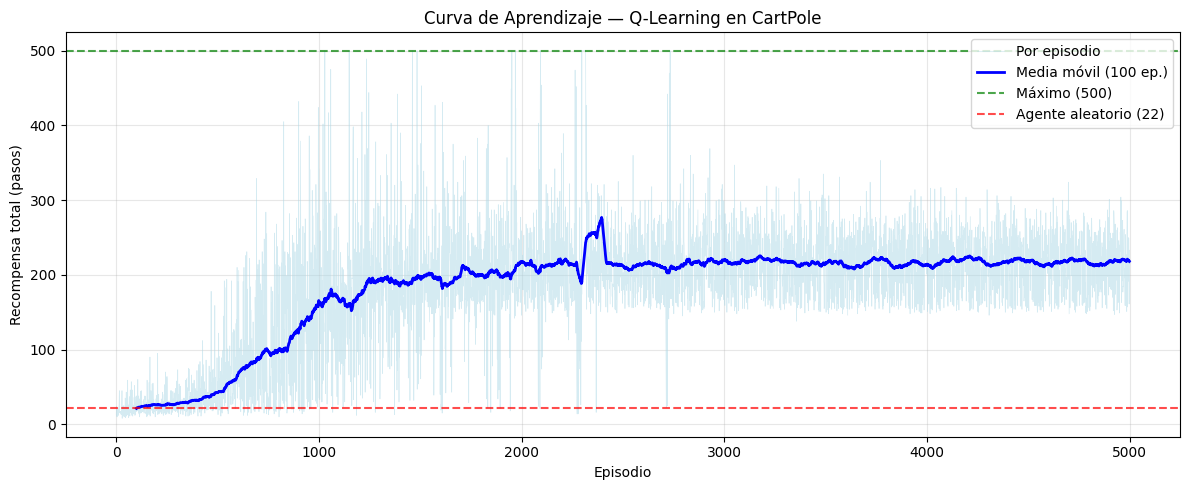

Rendimiento final (últimos 100 episodios): 218.0 pasos
Rendimiento agente aleatorio:              21.8 pasos
Mejora relativa:                           10.0x


In [50]:
# Gráfica de la curva de aprendizaje
window = 100
media_movil = np.convolve(recompensas_entrenamiento,
                          np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(recompensas_entrenamiento, color='lightblue', alpha=0.5, linewidth=0.5, label='Por episodio')
plt.plot(range(window-1, n_episodios), media_movil, color='blue', linewidth=2, label=f'Media móvil ({window} ep.)')
plt.axhline(500, color='green', linestyle='--', alpha=0.7, label='Máximo (500)')
plt.axhline(np.mean(recompensas_aleatorio), color='red', linestyle='--', alpha=0.7,
            label=f'Agente aleatorio ({np.mean(recompensas_aleatorio):.0f})')
plt.title('Curva de Aprendizaje — Q-Learning en CartPole')
plt.xlabel('Episodio')
plt.ylabel('Recompensa total (pasos)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Comparación
recompensa_final = np.mean(recompensas_entrenamiento[-100:])
print(f"Rendimiento final (últimos 100 episodios): {recompensa_final:.1f} pasos")
print(f"Rendimiento agente aleatorio:              {np.mean(recompensas_aleatorio):.1f} pasos")
print(f"Mejora relativa:                           {recompensa_final / np.mean(recompensas_aleatorio):.1f}x")

### Interpretación

La gráfica muestra que el agente logró un aprendizaje exitoso pero incompleto, pasando de un comportamiento aleatorio a uno que supera en 10 veces al azar. Tras una fase de crecimiento acelerado entre los episodios 500 y 1500, el rendimiento se estabilizó en una meseta de 218 pasos, lo que indica que, aunque el algoritmo es funcional y estable, se quedó estancado en un nivel subóptimo lejos del máximo teórico de 500 paso

### Evaluación del Agente

Se evaluará el agente en **modo explotación pura** (ε = 0): siempre usa la mejor acción según su Q-table, sin exploración aleatoria. La Q-table *es* el modelo aprendido. No necesitamos redes neuronales ni nada más sofisticado para este problema.

In [51]:
# Evaluación del agente entrenado (pura explotación)
env_eval = gym.make("CartPole-v1")
recompensas_evaluacion = []
n_episodios_eval = 100

for _ in range(n_episodios_eval):
    obs, info = env_eval.reset()
    estado = discretizar(obs, limites_inf, limites_sup, n_bins)
    recompensa_total = 0
    done = False

    while not done:
        # Solo explotación: ε = 0
        accion = np.argmax(Q[estado])
        obs, reward, terminated, truncated, _ = env_eval.step(accion)
        done = terminated or truncated
        estado = discretizar(obs, limites_inf, limites_sup, n_bins)
        recompensa_total += reward

    recompensas_evaluacion.append(recompensa_total)

env_eval.close()

# Estadísticas de evaluación
print("=== EVALUACIÓN DEL AGENTE ENTRENADO ===")
print(f"Episodios evaluados: {n_episodios_eval}")
print(f"Recompensa promedio: {np.mean(recompensas_evaluacion):.1f} pasos")
print(f"Recompensa máxima:   {np.max(recompensas_evaluacion):.0f} pasos")
print(f"Recompensa mínima:   {np.min(recompensas_evaluacion):.0f} pasos")
print(f"Episodios perfectos (500 pasos): {np.sum(np.array(recompensas_evaluacion) == 500)}")

# Comparación final
print(f"\n=== COMPARACIÓN FINAL ===")
print(f"Agente aleatorio: {np.mean(recompensas_aleatorio):.1f} pasos")
print(f"Agente Q-Learning: {np.mean(recompensas_evaluacion):.1f} pasos")
mejora = np.mean(recompensas_evaluacion) / np.mean(recompensas_aleatorio)
print(f"Mejora: {mejora:.1f}x mejor que el agente aleatorio")

=== EVALUACIÓN DEL AGENTE ENTRENADO ===
Episodios evaluados: 100
Recompensa promedio: 207.5 pasos
Recompensa máxima:   288 pasos
Recompensa mínima:   148 pasos
Episodios perfectos (500 pasos): 0

=== COMPARACIÓN FINAL ===
Agente aleatorio: 21.8 pasos
Agente Q-Learning: 207.5 pasos
Mejora: 9.5x mejor que el agente aleatorio


C:\Users\luzda\AppData\Local\Temp\ipykernel_11948\869463387.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([recompensas_aleatorio[:100], recompensas_evaluacion],


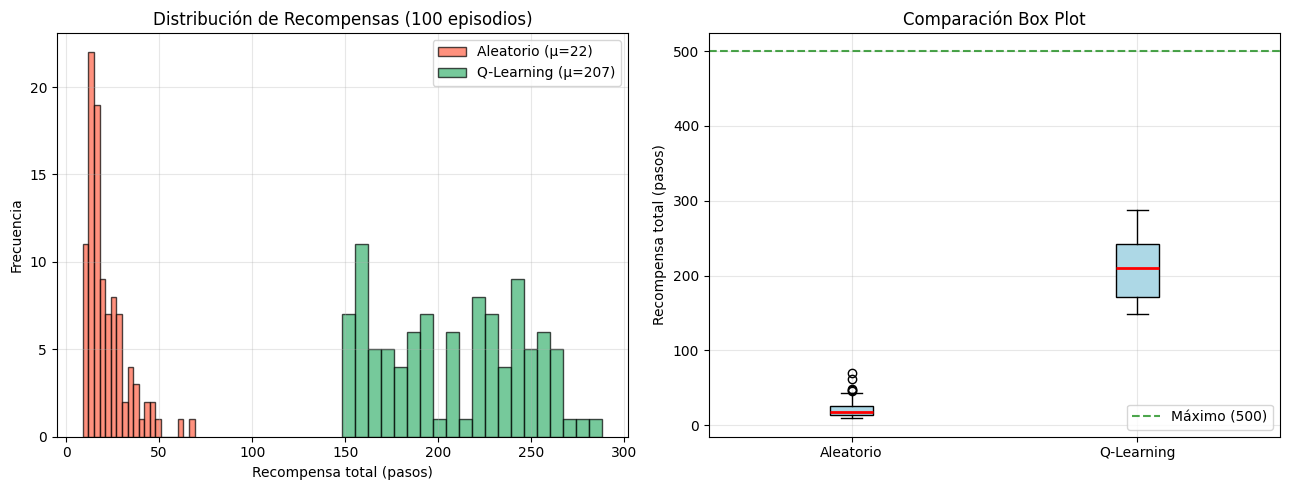

In [52]:
# Gráfica comparativa: agente aleatorio vs. Q-Learning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma comparativo
axes[0].hist(recompensas_aleatorio[:100], bins=20, color='tomato',
             alpha=0.7, label=f'Aleatorio (μ={np.mean(recompensas_aleatorio):.0f})', edgecolor='black')
axes[0].hist(recompensas_evaluacion, bins=20, color='mediumseagreen',
             alpha=0.7, label=f'Q-Learning (μ={np.mean(recompensas_evaluacion):.0f})', edgecolor='black')
axes[0].set_title('Distribución de Recompensas (100 episodios)')
axes[0].set_xlabel('Recompensa total (pasos)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparativo
axes[1].boxplot([recompensas_aleatorio[:100], recompensas_evaluacion],
                labels=['Aleatorio', 'Q-Learning'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].axhline(500, color='green', linestyle='--', alpha=0.7, label='Máximo (500)')
axes[1].set_title('Comparación Box Plot')
axes[1].set_ylabel('Recompensa total (pasos)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ¿Qué nos dicen los resultados de evaluación?

- La **diferencia entre el agente aleatorio y Q-Learning** es evidente: el agente entrenado dura muchos más pasos.
- Si el agente logra episodios de 500 pasos (el máximo), significa que ha aprendido a balancear el poste perfectamente.
- La **Q-table es el modelo**: no hay pesos de red neuronal, solo una tabla de valores aprendidos.

### Limitaciones de Q-Learning clásico

- **Maldición de la dimensionalidad**: con más variables o espacio de estados más complejo, la Q-table crece exponencialmente.
- **Discretización**: la resolución de los bins afecta la calidad del aprendizaje.
- **Solución**: para espacios de estado grandes/continuos, se usa **Deep Q-Learning** (DQN), donde una red neuronal aproxima la Q-function en lugar de una tabla.

## Conclusiones Integradas

### Multiple Testing

1. **El problema es real**: cuando realizamos muchas pruebas simultáneas, la probabilidad de falsos positivos acumulada puede ser muy alta.
2. **Corrección FWER** (Bonferroni, Holm): protege contra cualquier falso positivo, pero es muy conservadora. Ideal cuando pocas pruebas y máxima precisión.
3. **Corrección FDR** (Benjamini-Hochberg): permite algunos falsos positivos, pero detecta más efectos reales. Ideal en genómica, neuroimagen, big data.
4. **Intuición**: si buscamos con suficiente esfuerzo, siempre encontramos algo. La corrección de p-values es la protección contra esa trampa.

### Aprendizaje por Refuerzo

1. **RL aprende por interacción**: sin ejemplos etiquetados, el agente descubre qué acciones son buenas.
2. **Q-Learning converge**: con suficientes episodios, la Q-table aproxima la estrategia óptima.
3. **Exploración es necesaria**: sin exploración, el agente queda atrapado en estrategias subóptimas.
4. **La Q-table es el modelo**: simple pero efectivo para espacios de estado pequeños y discretizables.


Referencias:

- James, G., Witten, D., Hastie, T., Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
- Sutton, R.S. & Barto, A.G. (2018). *Reinforcement Learning: An Introduction*. MIT Press.

Código de Honor: Doy mi palabra de que he realizado esta actividad con integridad académica. 